# Github Actions 사용
* [Github Action 사용가이드](https://docs.github.com/ko/actions/get-started/quickstart)
* GitHub의 **GitHub Actions**는 코드 저장소에서 발생하는 이벤트를 기반으로
* **자동화된 작업(CI/CD)** 을 수행하는 기능
* 개발·배포·테스트·데이터 처리까지 자동화

# 1. Github Actions의 중요 구성요소

```yaml
#샘플 코드 : hi.yaml 워크플로우 파일
name: hi 워크플로우
on: push
jobs:
  hi:
    runs-on: ubuntu-latest
    steps:
      - run: echo "hi !!!"
      - uses: actions/checkout@v4
```


### <font color=red>1) Workflow</font>
* 자동화 전체 정의 파일 (`.github/workflows/*.yml` 또는 `.github/workflows/*.yaml` )

### <font color=red>2) Event:</font><font color=blue> **on** </font>
* 워크플로우 실행 트리거

<span style="display:inline-block;position:left;">
    
| 이벤트               | 설명         |
| ----------------- | ---------- |
| push              | 코드 푸시      |
| pull_request      | PR 생성      |
| schedule          | cron 자동 실행 |
| workflow_dispatch | 수동 실행      |

</span>

### <font color=red>3) Job</font>
* 하나의 작업 단위 (병렬 실행 가능)

### <font color=red>4) Step</font>
* Job 내부의 세부 실행 명령

```yaml
steps:
  - name: Checkout
    uses: actions/checkout@v4
```

## Github Actions 활용 실습하기
<font color=blue> **<선수조건>** </font>
* Github 계정 생성 > [Github 로그인](https://github.com)
* **New repository** 만들기
  > 이름: **cicd_work2**  
  > Description: **CI/CD 테스트**  
  > Add README 체크 후 <img src=attachment:f0aca1d2-f6e0-40c2-a22f-df2a14a9e08c.png>  
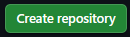

In [ ]:
# 윈도우 로그인 사용자 정보 확인
!whoami

In [ ]:
# 1.작업공간 만들기
!for /f "tokens=2 delims=\" %i in ('whoami') do mkdir c:\Users\%i\github_actions

In [ ]:
# 2. 위 생성된 결과값 복사하여 붙여넣기(작업공간으로 이동)
%cd c:\Users\master\github_actions

In [ ]:
# 2-1. 작업 디렉토리 확인하기
%pwd

In [ ]:
# 3. github에서 만든 cicd_work2 저장소 가져오기
#!git clone https://github.com/[본인의githubID로 변경]/cicd_work2.git 
!git clone https://github.com/yoojaemyeong/cicd_work2.git 

In [ ]:
# 3-1. 위 복사한 저장소로 이동
%cd cicd_work2

In [ ]:
# 4. 윈도우 탐색기를 열어 cicd_work폴더에서 윈도우 명령 프롬프트 열기
!mkdir .github\workflows 

In [ ]:
# 4-1. 현재까지 작업 상태 보기
!tree /F /A

## 5. workflows 폴더에 <font color=red>hi.yaml</font> 파일 생성하기 

---  

```yaml
name: hi
on: push
jobs:
  hi:
    runs-on: ubuntu-latest
    steps:
      - run: echo "hi !!!"
      - uses: actions/checkout@v4
```

---  

In [ ]:
# hi.yaml 생성하기: 아래 스크립트 실행 후 위 코드 복사 > 저장 후 메모장 닫기
!notepad .github\workflows\hi.yaml

## 6. 차례대로 add, commit, push
* **git add .github\workflows\hi.yaml** 
* **git commit -m "CI/CD를 위한 워크플로우 추가"**
* **git push origin main**

In [ ]:
# Staging Area로 이동
!git add .github\workflows\hi.yaml

In [ ]:
# 로컬저장소(.git 폴더)에 기록
!git commit -m "CI/CD를 위한 워크플로우 추가"

In [ ]:
# 원격저장소와 동기화
!git push origin main

## 7. Github의 **cicd_work** 저장소를 선택하고 **Actions** 메뉴 클릭 
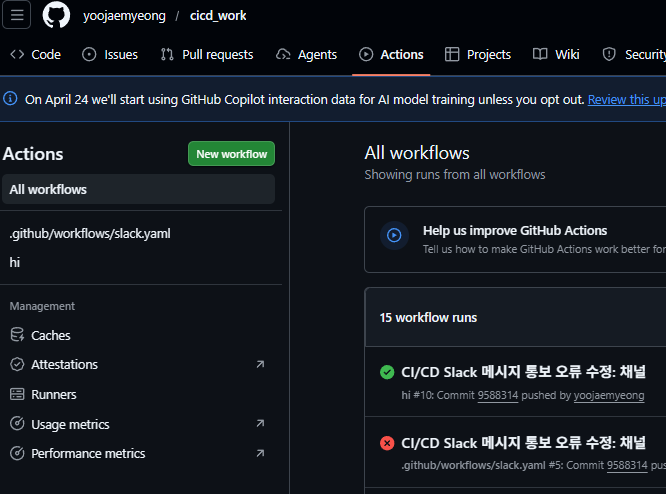

## 8. Github Actions CI/CD 테스트

### <font color=red>1. workflows 업데이트</font>
* hi.yaml 파일 내용 수정

---  

```yaml
name: hi 워크플로우
on:
  push:
    branches:
      - main
jobs:
  hi:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - run: pwd && ls && cat /etc/lsb-release
      
```
---  

In [ ]:
# hi.yaml 업데이트 1: 아래 스크립트 실행하여 변경된 코드 복사 > 저장 후 메모장 닫기
!notepad .github\workflows\hi.yaml

* 수정후 작업  
  > **git add .github\workflows\hi.yaml**  
  > **git commit -m "CI/CD를 위한 워크플로우 작업 변경1"**  
  > **git push origin main**  


In [ ]:
# Staging Area로 이동
!git add .github\workflows\hi.yaml

In [ ]:
# 로컬저장소(.git 폴더)에 기록
!git commit -m "CI/CD를 위한 워크플로우 작업 변경1"

In [ ]:
# 원격저장소와 동기화
!git push origin main

### <font color=red>2. workflosw 두번째 작업</font>
* hi.yaml 파일 내용 수정

---  
```yaml
name: hi 워크플로우
on:
  push:
    branches:
      - main
jobs:
  hi:
    runs-on: ubuntu-latest
    steps:
      - name: 데이터 이동
        uses: actions/checkout@v4
      - name: 명령어 추가
        run: |
          echo "USER: $(whoami)"
          echo "HOME: $HOME"
          echo "PWD: $(pwd)"
          echo "HOSTNAME: $(hostname)"
      
```
---


In [ ]:
# hi.yaml 업데이트 2: 아래 스크립트 실행하여 변경된 코드 복사 > 저장 후 메모장 닫기
!notepad .github\workflows\hi.yaml


* 수정후 두번째 작업
  > **git add .github\workflows\hi.yaml**  
  > **git commit -m "CI/CD hi.yaml 명령어 수정"**  
  > **git push origin main**  


In [ ]:
# Staging Area로 이동
!git add .github\workflows\hi.yaml

In [ ]:
# 로컬저장소(.git 폴더)에 기록
!git commit -m "CI/CD를 위한 워크플로우 작업 변경2"

In [ ]:
# 원격저장소와 동기화
!git push origin main

## <font color=red>Github 저장소의 <img src=attachment:91849436-7724-49b0-bc75-031d013b4916.png>에서 CI/CD 변경사항 확인

# Slack 채널 만드는 방법
* [Slack 사이트 app.slack.com](https://slack.com)
* <font color=red>새 이메일로 로그인 > 채널 추가</font>
---

## PC 앱 / 웹 브라우저 기준

### STEP 1. 채널 추가 버튼 클릭
```
왼쪽 사이드바
→ "채널" 옆에 + 버튼 클릭  
```

### STEP 2. 채널 만들기 선택
```
드롭다운 메뉴
→ "채널 만들기" 클릭
```

### STEP 3. 채널 정보 입력
```
채널 이름:  deploy          ← 소문자, 하이픈 사용 가능
                               예) sosd-deploy, github-alerts  

설명 (선택): 배포 알림 채널  ← 선택사항

공개 여부:
  ● 공개  - 워크스페이스 누구나 참여 가능
  ○ 비공개 - 초대된 멤버만 참여 가능

```

### STEP 4. 만들기 클릭
```
→ "만들기" 버튼 클릭
→ 채널 생성 완료 ✅
```

# Slack 봇 만들기
* [https://api.slack.com/apps](https://api.slack.com/apps)
→ Create New App 클릭 → From scratch 선택
### (1) 앱 이름 & 워크스페이스 설정
```
App Name: GitHub Deploy Bot    ← 원하는 이름
Workspace: 내 워크스페이스      ← 알림 받을 워크스페이스 선택
→ Create App  클릭
```
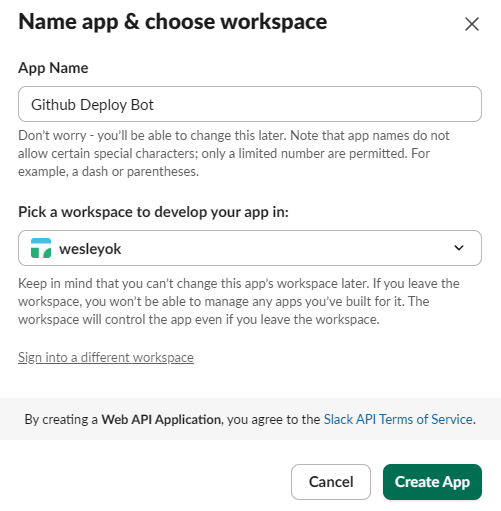

### (2) OAuth & Permissions 메뉴 이동
```
왼쪽 메뉴 → OAuth & Permissions
```  
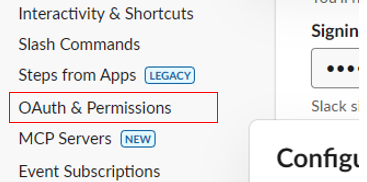

### (3) Scopes 추가 (Bot Token Scopes)

Scopes 섹션 → Add an OAuth Scope 클릭

추가할 권한: 

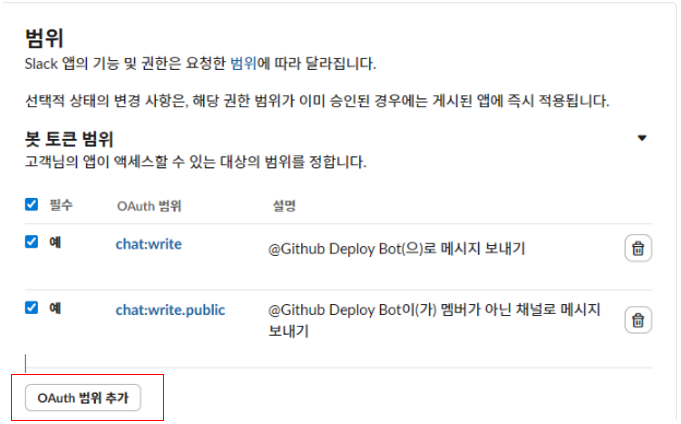

### (4) 워크스페이스에 설치
<img src=attachment:85566318-0cc9-4e5b-ab1a-14a937e59abc.png border=1> 
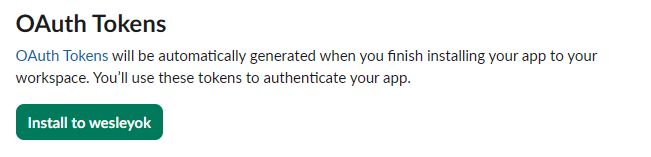

<img src=attachment:a2c98ed7-cfeb-46bf-be9e-c0fb4fbea39c.png border=1>
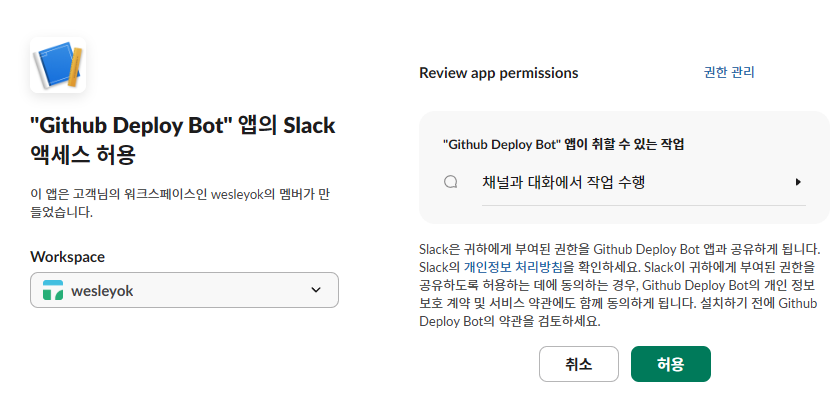

<img src=attachment:ad4974d4-4f69-4091-b704-b7801ec1787b.png border=1>  

* **토큰을 복사하여 Github > cicd_work저장소 > Settings > Secrets and Valuables > Actions**에서 활용
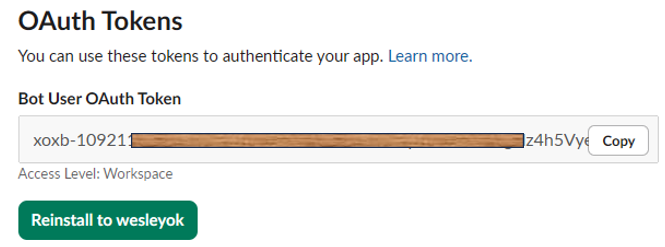

### (5) Slack 채널에 Bot초대
  
1. Slack 앱 사이드바
2. **#deploy 채널** 클릭
3. 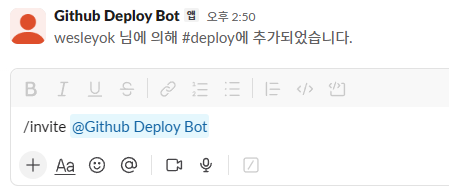
4. /invite @Github Deploy Bot
* 확인 메시지: ~~ #deploy에 추가되었습니다.

### (6) Github Secrets 등록
* cicd_work 저장소의 `Settings` 에서
  > Secrets and variables ->  Actions ->    
  > **New repository secret**  
  > 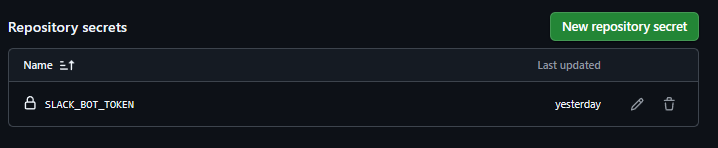
* 정보입력
  > Name: **SLACK_BOT_TOKEN**  
  > Secret: **(5)에서 복사한 토큰 입력**    

### <font color=red>3. Slack 봇 알림 테스트</font>
* hi.yaml 파일 내용 수정

---  
```yaml
name: hi 워크플로우
on:
  push:
    branches:
      - main
jobs:
  hi:
    runs-on: ubuntu-latest
    steps:
      - name: 데이터 이동
        uses: actions/checkout@v4
      - name: 명령어 추가
        run: |
          echo "USER: $(whoami)"
          echo "HOME: $HOME"
          echo "PWD: $(pwd)"
          echo "HOSTNAME: $(hostname)"
      - name: Slack 성공 알림
        if: success()
        run: |
          curl -X POST https://slack.com/api/chat.postMessage \
            -H "Authorization: Bearer ${{ secrets.SLACK_BOT_TOKEN }}" \
            -H "Content-type: application/json" \
            --data "{
              \"channel\": \"#deploy\",
              \"text\": \"✅ 배포 성공!\"
              }"

      - name: Slack 실패 알림
        if: failure()
        run: |
          curl -X POST https://slack.com/api/chat.postMessage \
            -H "Authorization: Bearer ${{ secrets.SLACK_BOT_TOKEN }}" \
            -H "Content-type: application/json" \
            --data "{
              \"channel\": \"#deploy\",
              \"text\": \"❌ 배포 실패!\"
              }"
```
---  

* 수정후 작업
  > **git add .github\workflows\hi.yaml**  
  > **git commit -m "CI/CD hi.yaml Slack 메시지 통보 추가"**  
  > **git push origin main**
  

## 워크플로우 종류(개발: develop)

```yaml
name: 개발 서버 자동 배포

on:
  push:
    branches:
      - develop

jobs:
  deploy:
    runs-on: ubuntu-latest

    steps:
      - name: Check runner environment
        run: |
          echo "USER: $(whoami)"
```

## 워크프로우 종류(배포: published)

```yaml
name: 상용 서버 릴리즈 기반 자동 배포

on:
  release:
    types: [published]

jobs:
  deploy:
    runs-on: ubuntu-latest

    steps:
      - name: Check runner environment
        run: |
          echo "USER: $(whoami)"
          echo "HOME: $HOME"
          echo "PWD: $(pwd)"
          echo "HOSTNAME: $(hostname)"
```
